In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline

In [8]:
#y = 0.8 * x^2 + 0.9 * X + 2
X = 6 * np.random.rand(200,1)-3
y = 0.8 * X ** 2 + 0.9 * X + 2 + np.random.randn(200,1)

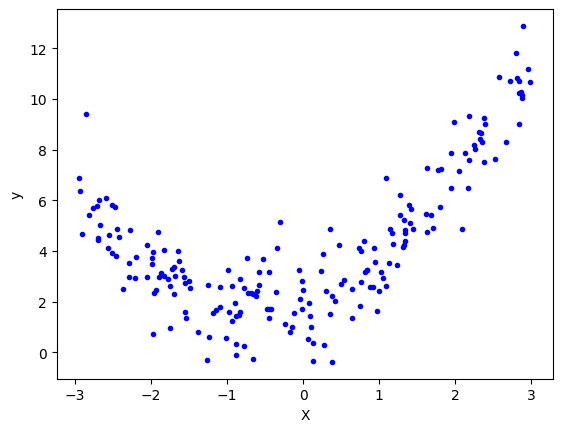

In [9]:
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [10]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [11]:
# Applying linear regression
lr = LinearRegression()

In [12]:
lr.fit(X_train,y_train)

LinearRegression()

In [13]:
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)

0.10333695313135083

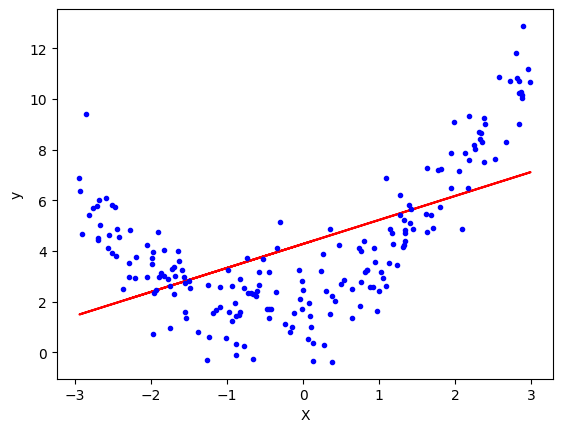

In [14]:
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [15]:
# Applying Polynomial LR
poly = PolynomialFeatures(degree = 2,include_bias=True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

In [16]:
print(X_train[0])
print(X_train_trans[0])

[0.12649213]
[1.         0.12649213 0.01600026]


In [17]:
lr = LinearRegression()
lr.fit(X_train_trans,y_train)

LinearRegression()

In [19]:
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)

0.736332213227967

In [20]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.9010226  0.75470839]]
[2.06388567]


In [30]:
X_new = np.linspace(-3, 3, 100).reshape(100, 1)  # Create data for X_new
X_new_poly = poly.transform(X_new) # Transform X_new using the polynomial features
y_new = lr.predict(X_new_poly)

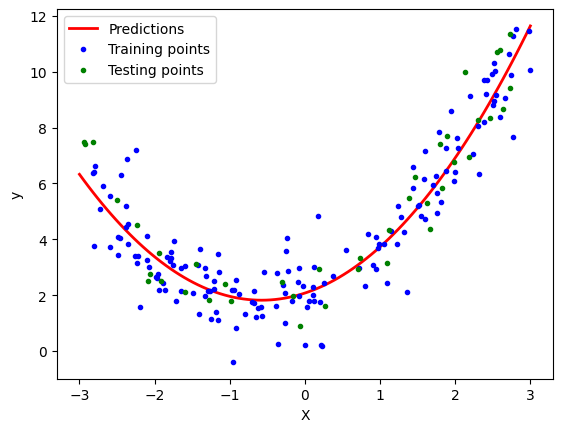

In [33]:
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

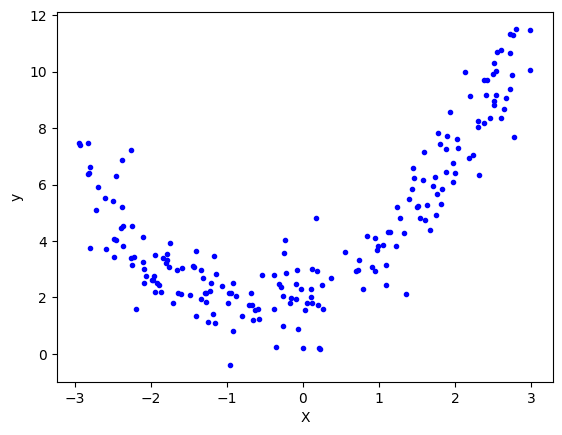

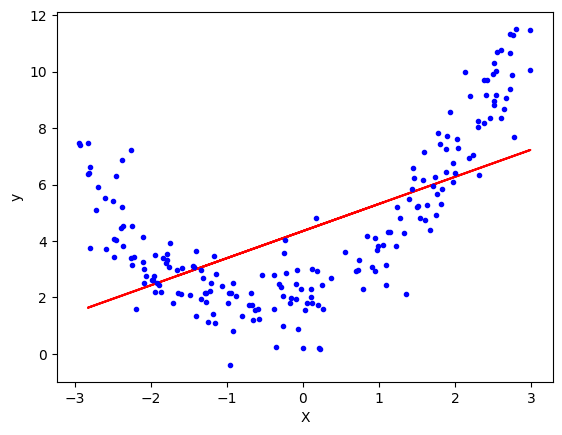

[1.05722791]
[1.         1.05722791 1.11773086]
[[0.         0.88574674 0.76783377]]
[2.07543718]


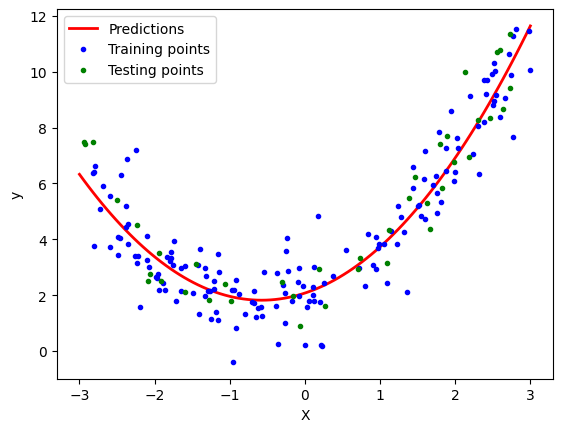

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.metrics import r2_score
from sklearn.pipeline import Pipeline
# %%
#y = 0.8 * x^2 + 0.9 * X + 2
X = 6 * np.random.rand(200,1)-3
y = 0.8 * X ** 2 + 0.9 * X + 2 + np.random.randn(200,1)
# %%
plt.plot(X,y,'b.')
plt.xlabel('X')
plt.ylabel('y')
plt.show()
# %%
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)
# %%
# Applying linear regression
lr = LinearRegression()
# %%
lr.fit(X_train,y_train)
# %%
y_pred = lr.predict(X_test)
r2_score(y_test,y_pred)
# %%
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.xlabel("X")
plt.ylabel("y")
plt.show()
# %%
# Applying Polynomial LR
poly = PolynomialFeatures(degree = 2,include_bias=True)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)
# %%
print(X_train[0])
print(X_train_trans[0])
# %%
lr = LinearRegression()
lr.fit(X_train_trans,y_train)
# %%

# %%
y_pred = lr.predict(X_test_trans)
r2_score(y_test,y_pred)
# %%
print(lr.coef_)
print(lr.intercept_)
# %%
# Define X_new and y_new before using them in the plot
X_new = np.linspace(-3, 3, 100).reshape(100, 1)  # Create data for X_new
X_new_poly = poly.transform(X_new) # Transform X_new using the polynomial features
y_new = lr.predict(X_new_poly)  # Predict y_new using the trained model


plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()
# %%
def polynomial_regression(degree):
    X_new=np.linspace(-3, 3, 100).reshape(100, 1)
    X_new_poly = poly.transform(X_new)

    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
            ("poly_features", polybig_features),
            ("std_scaler", std_scaler),
            ("lin_reg", lin_reg),
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig,'r', label="Degree " + str(degree), linewidth=2)

    plt.plot(X_train, y_train, "b.", linewidth=3)
    plt.plot(X_test, y_test, "g.", linewidth=3)
    plt.legend(loc="upper left")
    plt.xlabel("X")
    plt.ylabel("y")
    plt.axis([-3, 3, 0, 10])
    plt.show()
# %%